Debug notebook to output bottom-layer metabolic index data for all species and three selected nodes

In [1]:
case_dir = '/home/benr/wqmodels/ssm/psi/SalishSeaModel-analysis/metabolic_index/run'

case_file = 'SSM_config_mi.yaml'

specified_nodes = [13789, 8841, 14409]

import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd

sys.path.append('../py_scripts')
from ssm_utils import read_case, FileFinder

In [2]:
os.chdir(case_dir)
ssm, case = read_case(case_file)

In [3]:
ffs = {}
output_dirs = []
for species in ('salmon','crab','sole'):
    ffs[species] = FileFinder(case=case, ssm_config=ssm, vtype='mi',
                             mispecies=species, mitype='routine')
    output_dirs.append(ffs[species].processed_netcdf_dir)

output_dirs

[PosixPath('SSM_data/mi/mi'),
 PosixPath('SSM_data/mi/mi'),
 PosixPath('SSM_data/mi/mi')]

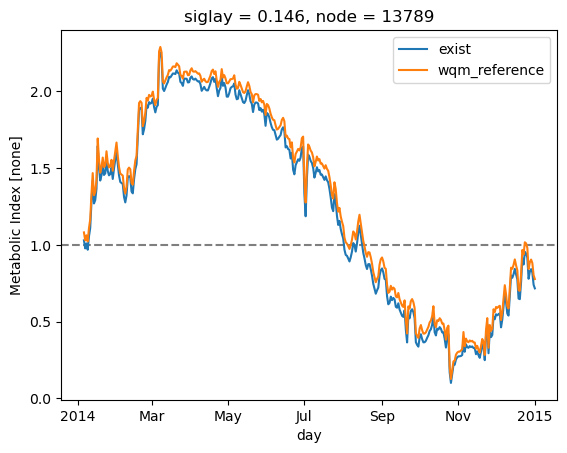

In [4]:
for species, ff in ffs.items():
    fig, ax = plt.subplots()
    ax.axhline(1, linestyle='--', color='tab:gray')
    for run_tag in ssm['run_information']['run_tag'][case].keys():
        f = ff.get_file(run_tag, 'min')
        with xr.open_dataset(f) as mi_data:
            var = ff.get_var_name(f)
            mi_data[var][:,-1,specified_nodes[0]-1].plot(ax=ax, label=run_tag)
            times = mi_data['day'][:]
    break
ax.legend()

In [5]:
dfs = {}
for species,ff in ffs.items():
    data = {}
    for node in specified_nodes:
        data[node] = {}
    for run_tag in ssm['run_information']['run_tag'][case].keys():
        f = ff.get_file(run_tag, 'min')
        with xr.open_dataset(f) as mi_data:
            var = ff.get_var_name(f)
            for node in specified_nodes:
                data[node][run_tag] = mi_data[var][:,-1,node-1].to_pandas()
    dfs[species] = {}
    for node in specified_nodes:
        df = pd.DataFrame(data[node])
        df.to_excel(Path(ssm['paths']['spreadsheets']) / f'{ff.output_var_base}_node{node}.xlsx')
        dfs[species][node] = df